In [24]:
import pyreadr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join as pjoin
import pandas as pd
from sklearn.decomposition import PCA
from pcpca import CPCA

In [2]:
DATA_DIR = "../data/genentech/"

In [3]:
data_old = pd.read_csv(pjoin(DATA_DIR, "small_intestine_old_counts.csv"), index_col=0)
data_young = pd.read_csv(pjoin(DATA_DIR, "small_intestine_young_counts.csv"), index_col=0)
assert np.array_equal(data_old.columns.values, data_young.columns.values)

cell_types_old = pd.read_csv(pjoin(DATA_DIR, "small_intestine_old_cell_types.csv"), index_col=0)
cell_types_young = pd.read_csv(pjoin(DATA_DIR, "small_intestine_young_cell_types.csv"), index_col=0)

In [4]:
data_old.head()

,ENSMUSG00000024029,ENSMUSG00000028415,ENSMUSG00000020581,ENSMUSG00000049350,ENSMUSG00000064213,ENSMUSG00000020405,ENSMUSG00000071356,ENSMUSG00000025515,ENSMUSG00000047730,ENSMUSG00000023247,...,ENSMUSG00000022570,ENSMUSG00000059534,ENSMUSG00000049493,ENSMUSG00000021546,ENSMUSG00000025203,ENSMUSG00000022452,ENSMUSG00000027230,ENSMUSG00000027133,ENSMUSG00000069744,ENSMUSG00000039640
LIB4583376_SAM24359875_TACTCATTCTGCGTAA-1,2.515496,4.802313,1.681853,0.680136,10.466870,1.967564,1.204743,0.263952,0.138004,2.705092,...,0.138004,0.850443,0.138004,0.263952,0.000000,0.263952,0.0,0.138004,0.000000,0.263952
LIB4583376_SAM24359875_GGACAAGGTAAGGGAA-1,2.517692,6.479470,1.727183,0.506040,10.581016,1.978572,1.582892,1.242131,0.000000,3.133023,...,0.275095,0.608983,0.000000,0.144094,0.000000,0.395184,0.0,0.275095,0.000000,0.144094
LIB4583376_SAM24359875_CCATTCGAGCACCGTC-1,2.617197,4.823590,2.482650,0.523130,10.522771,0.987981,1.812766,0.906228,0.149607,2.021298,...,0.285148,0.409040,0.000000,0.285148,0.000000,0.628855,0.0,0.285148,0.285148,0.000000
LIB4583376_SAM24359875_TCTTTCCCAGACACTT-1,2.253581,5.291220,2.022201,0.436493,10.485978,1.405331,1.339716,0.867416,0.000000,2.180501,...,0.305143,0.436493,0.160624,0.305143,0.436493,0.160624,0.0,0.160624,0.160624,0.305143
LIB4583376_SAM24359875_AGCGGTCTCATTCACT-1,2.537683,5.577928,1.739125,0.176204,10.574904,1.681863,1.739125,1.028043,0.000000,2.661336,...,0.333211,0.831425,0.176204,0.176204,0.176204,0.831425,0.0,0.333211,0.333211,0.000000


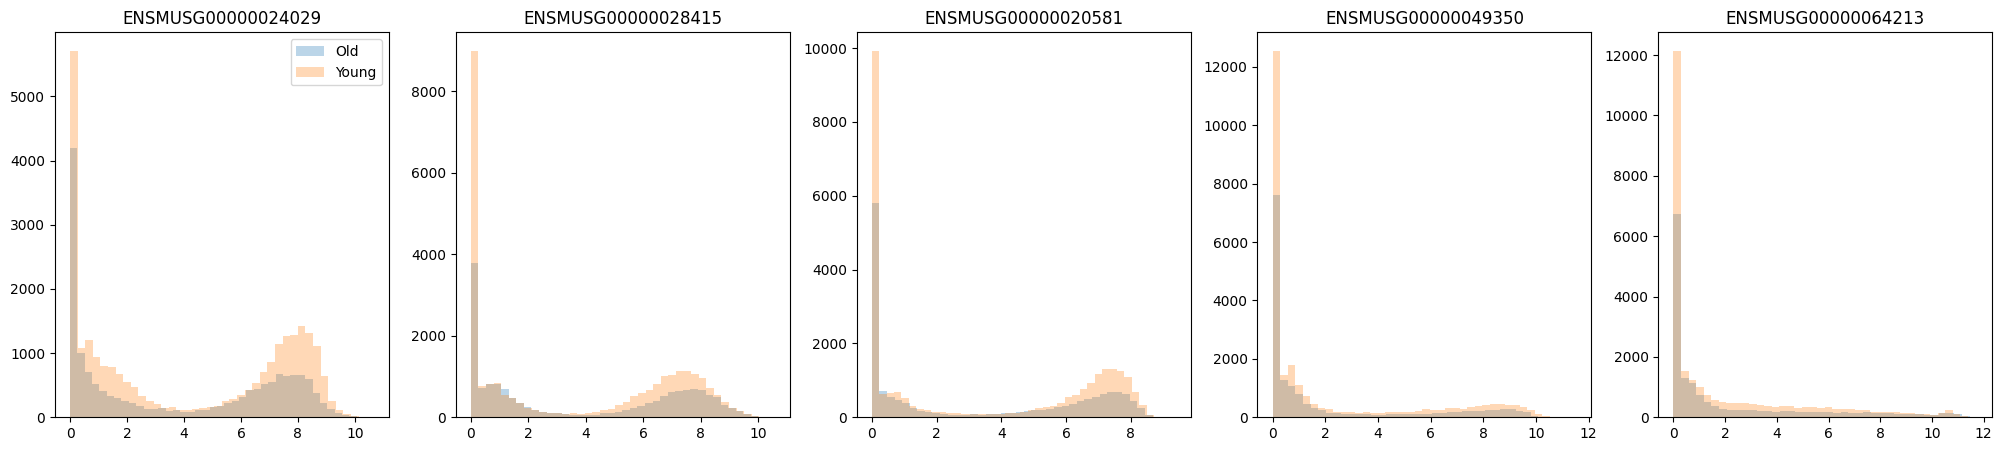

In [5]:
plt.figure(figsize=(25, 5))
for ii in range(5):
    plt.subplot(1, 5, ii + 1)
    plt.hist(data_old.iloc[:, ii], 40, alpha=0.3, label="Old")
    plt.hist(data_young.iloc[:, ii], 40, alpha=0.3, label="Young")
    plt.title(data_old.columns.values[ii])
    if ii == 0:
        plt.legend()
plt.show()

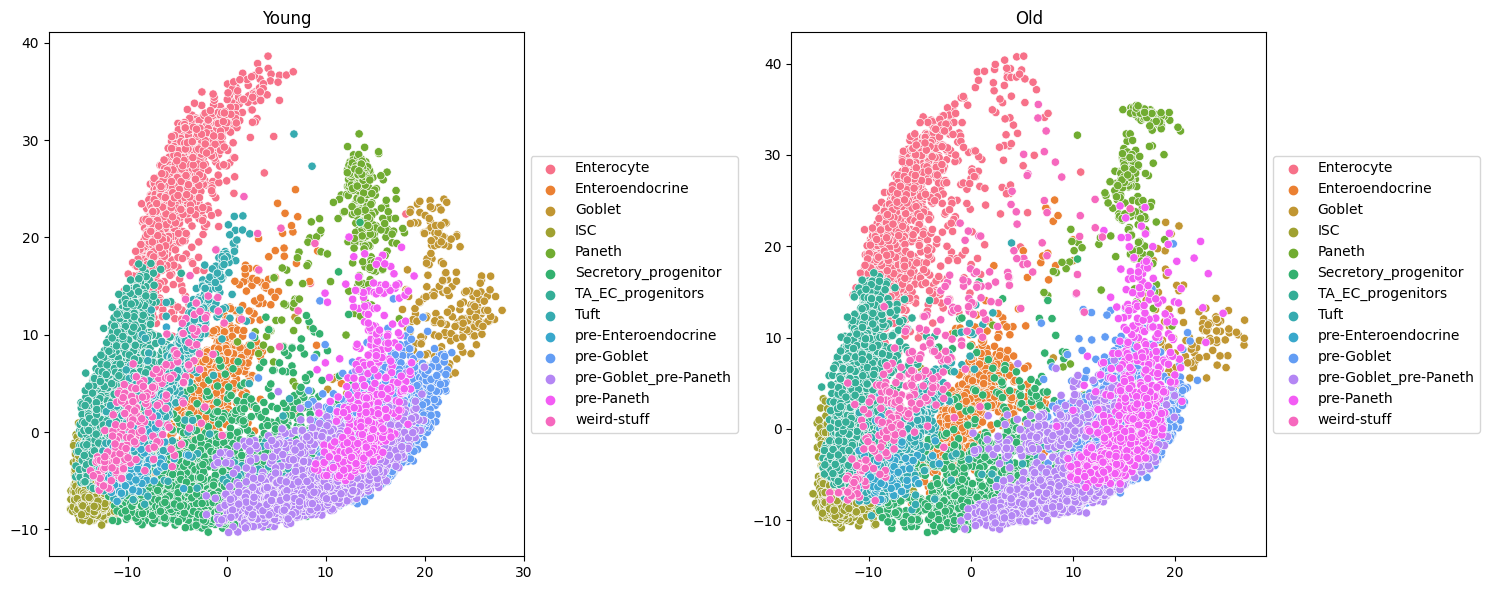

In [23]:
pca = PCA(n_components=2)
data_young_reduced = pca.fit_transform(data_young.values)
data_old_reduced = pca.fit_transform(data_old.values)

plt.figure(figsize=(15, 6))
plt.subplot(121)
sorted_idx = np.argsort(cell_types_young.values.squeeze())
sns.scatterplot(x=data_young_reduced[sorted_idx][:, 0], y=data_young_reduced[sorted_idx][:, 1], hue=cell_types_young.values.squeeze()[sorted_idx])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Young")
plt.subplot(122)
sorted_idx = np.argsort(cell_types_old.values.squeeze())
sns.scatterplot(x=data_old_reduced[sorted_idx][:, 0], y=data_old_reduced[sorted_idx][:, 1], hue=cell_types_old.values.squeeze()[sorted_idx])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Old")
plt.tight_layout()
plt.show()

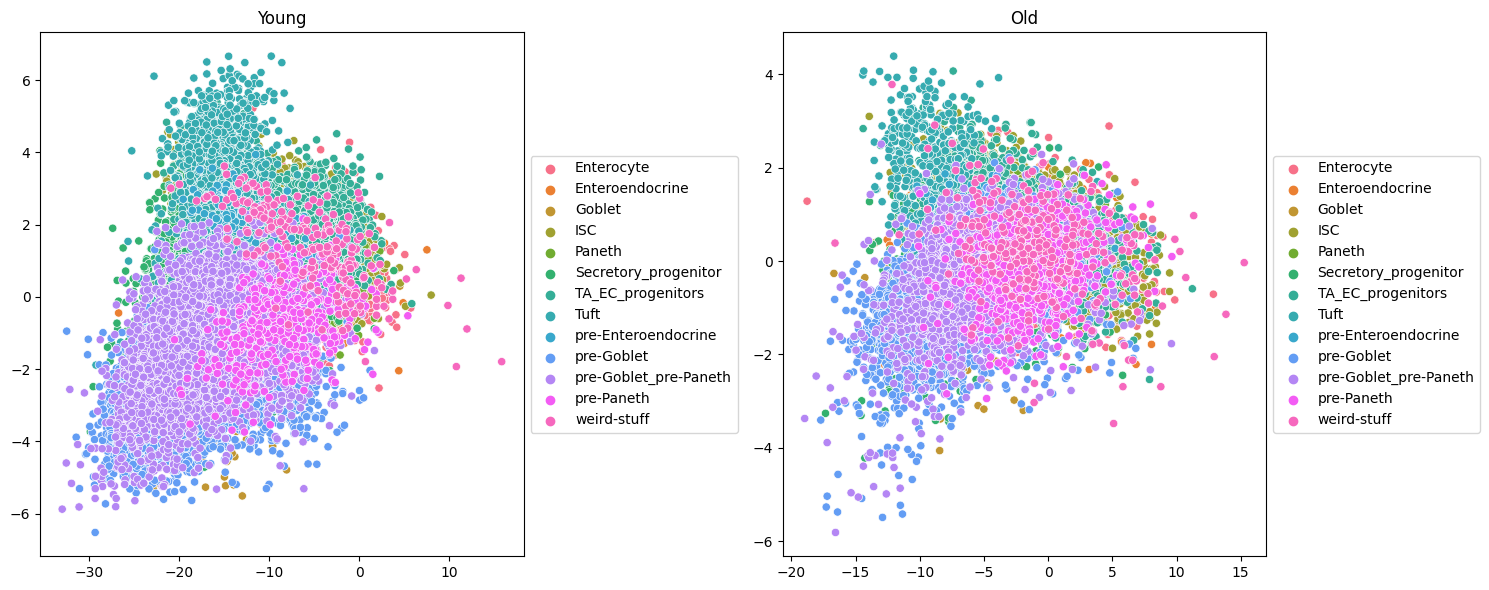

In [36]:
cpca = CPCA(n_components=2, gamma=3)
data_young_reduced, data_old_reduced = cpca.fit_transform(X=data_young.values.T, Y=data_old.values.T)
data_young_reduced, data_old_reduced = data_young_reduced.T, data_old_reduced.T

plt.figure(figsize=(15, 6))
plt.subplot(121)
sorted_idx = np.argsort(cell_types_young.values.squeeze())
sns.scatterplot(x=data_young_reduced[sorted_idx][:, 0], y=data_young_reduced[sorted_idx][:, 1], hue=cell_types_young.values.squeeze()[sorted_idx])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Young")
plt.subplot(122)
sorted_idx = np.argsort(cell_types_old.values.squeeze())
sns.scatterplot(x=data_old_reduced[sorted_idx][:, 0], y=data_old_reduced[sorted_idx][:, 1], hue=cell_types_old.values.squeeze()[sorted_idx])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Old")
plt.tight_layout()
plt.show()